# Data Analytics Final Project — Heart Failure Dataset

**Dataset:** `HeartFailureDataset.csv`  
Rows: **70000**, Columns: **13**



---



##  Introduction
This project analyzes **Heart Failure Dataset collected from **Kaggle**.  

The main purpose of this project is to analyze patient health records and prepare the data for further exploratory analysis and predictive modeling.
The dataset used in this study contains multiple health indicators such as age, gender, blood pressure readings (systolic and diastolic), cholesterol levels, glucose level, and lifestyle habits like smoking, alcohol consumption, and physical activity.

**Objectives:**
-Analyzing this data allows us to discover meaningful insights that can lead to better diagnosis, preventive care, and optimized treatment strategies.

We use Python libraries like **Pandas** for data cleaning and manipulation, and **Matplotlib** for visualization and trend analysis.

---


## Dataset Description

This dataset contains detailed healthcare information of patients collected from a clinical database. It includes demographic details, medical measurements, and lifestyle indicators that can be used to study the relationship between these factors and the occurrence of cardiovascular diseases.

Attributes:

id – Unique identification number assigned to each patient record.

age – Age of the patient (initially recorded in days; converted to years during preprocessing).

gender – Gender of the patient (1 = Male, 2 = Female).

height – Height of the patient in centimeters (cm).

weight – Weight of the patient in kilograms (kg).

ap_hi – Systolic blood pressure (the higher number in a BP reading, e.g., 120 in 120/80).

ap_lo – Diastolic blood pressure (the lower number in a BP reading, e.g., 80 in 120/80).

cholesterol – Cholesterol level of the patient (1 = normal, 2 = above normal, 3 = well above normal).

gluc – Glucose level in the patient’s blood (1 = normal, 2 = above normal, 3 = well above normal).

smoke – Indicates if the patient is a smoker (1 = Yes, 0 = No).

alco – Indicates if the patient consumes alcohol (1 = Yes, 0 = No).

active – Indicates if the patient is physically active (1 = Yes, 0 = No).

cardio – Target variable representing the presence of cardiovascular disease (1 = Disease, 0 = No disease).


### Import Libraries

In [2]:
import pandas as pd
import numpy as np
from IPython.display import display

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)


## 1. Data Loading and Initial Overview

Load the dataset and display the shape, dtypes, head, info(), and describe().

In [3]:
# 1.1 Load dataset

df = pd.read_csv(
    r"C:\Users\sumay\OneDrive\Desktop\HeartFailureDataset.csv"
)
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62,110,80,1,1,0,0,1,0
1,1,20228,1,156,85,140,90,3,1,0,0,1,1
2,2,18857,1,165,64,130,70,3,1,0,0,0,1
3,3,17623,2,169,82,150,100,1,1,0,0,1,1
4,4,17474,1,156,56,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76,120,80,1,1,1,0,1,0
69996,99995,22601,1,158,126,140,90,2,2,0,0,1,1
69997,99996,19066,2,183,105,180,90,3,1,0,1,0,1
69998,99998,22431,1,163,72,135,80,1,2,0,0,0,1


### Dataset Overview — Shape of the Data

Before performing any analysis, it is essential to understand the size and structure of the dataset.
Using the .shape attribute in Pandas, we can determine how many rows (data records representing individual patients) and columns (features describing each patient’s health condition) the dataset contains.

In [4]:
print("Shape of the dataset:", df.shape)

Shape of the dataset: (70000, 13)


### Dataset Information — Data Types and Non-Null Values

To better understand the structure of the dataset, we can use the info() function.
It provides a concise summary including:Column names,Data types (e.g., object, float, int),Number of non-null (non-missing) values in each column

In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   id           70000 non-null  int64
 1   age          70000 non-null  int64
 2   gender       70000 non-null  int64
 3   height       70000 non-null  int64
 4   weight       70000 non-null  int64
 5   ap_hi        70000 non-null  int64
 6   ap_lo        70000 non-null  int64
 7   cholesterol  70000 non-null  int64
 8   gluc         70000 non-null  int64
 9   smoke        70000 non-null  int64
 10  alco         70000 non-null  int64
 11  active       70000 non-null  int64
 12  cardio       70000 non-null  int64
dtypes: int64(13)
memory usage: 6.9 MB


### Display the First Few Rows of the Dataset

To get a quick look at the structure and content of the dataset, we use the head() function.
This displays the rows of the dataset by default.

In [6]:
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62,110,80,1,1,0,0,1,0
1,1,20228,1,156,85,140,90,3,1,0,0,1,1
2,2,18857,1,165,64,130,70,3,1,0,0,0,1
3,3,17623,2,169,82,150,100,1,1,0,0,1,1
4,4,17474,1,156,56,100,60,1,1,0,0,0,0


### Statistical Summary of the Dataset

The .describe() function in Pandas provides a detailed statistical summary of all the numerical columns in the dataset.
It helps us understand the central tendency, spread, and distribution of the data, offering valuable insight into how each health attribute varies among patients.

In [7]:
df.describe()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,1.349571,164.359229,74.205543,128.817714,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,28851.302323,2467.251667,0.476838,8.210126,14.395829,154.011381,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.750000,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,50001.500000,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74889.250000,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


## 2. Data Pre-processing 
Data pre-processing is an essential step before analysis. It ensures that the dataset is clean, consistent, and ready for visualization or modeling.

### 2.1 Handling missing values
This command checks for missing or null values in each column of the dataset.
It helps identify incomplete records that may need cleaning, filling, or removal before analysis.

In [8]:
# Check for missing values
df.isnull().sum()

id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

### 2.2 Removing duplicates 
Before performing any analysis, it’s important to ensure that the dataset contains unique and reliable records. Duplicate rows can occur due to repeated entries during data collection and can lead to incorrect summaries or misleading visualizations.
In this step, we remove all duplicate entries to maintain data accuracy.

In [9]:
# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Confirm dataset shape after removal
df.shape


(70000, 13)

### 2.3 Correcting data types 

Before performing any analysis, it’s important to ensure that each column has the correct data type (for example, numeric values should not be stored as strings).

In [10]:
print(df.dtypes)

id             int64
age            int64
gender         int64
height         int64
weight         int64
ap_hi          int64
ap_lo          int64
cholesterol    int64
gluc           int64
smoke          int64
alco           int64
active         int64
cardio         int64
dtype: object


# 2.4  Derived columns: Age Group 

In [11]:
# Convert 'age' from days to years if needed
if df['age'].mean() > 120:
    df['age_years'] = (df['age'] / 365).round(1)
    print("Converted 'age' from days to years.")
else:
    df['age_years'] = df['age']
    print("Age already in years.")

# Create Age Group categories
bins = [0, 12, 19, 31, 46, 61, 76, 101]
labels = ['Child', 'Teen', 'Young Adult', 'Adult', 'Mid-age', 'Senior', 'Elder']

df['age_group'] = pd.cut(df['age_years'], bins=bins, labels=labels, right=False)

print("Created 'age_group' based on 'age_years' column.")


Converted 'age' from days to years.
Created 'age_group' based on 'age_years' column.


### 2.5 Filtering & Aggregation templates
Use these templates to filter or aggregate the dataset for downstream analysis. Adjust column names as needed.

In [12]:
# Filter example: patients older than 60 (if age exists)
if 'age_group' in df.columns:
    seniors = df[df['age_group'] == 'Senior (61-75)']
    print('Seniors count:', seniors.shape[0])

# Aggregation example: count by age_group
if 'age_group' in df.columns:
 display(df.groupby('age_group', observed=True).size().reset_index(name='count'))




Seniors count: 0


,age_group,count
0,Young Adult,4
1,Adult,12178
2,Mid-age,47965
3,Senior,9853


## 3. Exploratory Data Analysis (EDA)

EDA helps us understand the patterns, relationships, and distribution of key health features before building any model.

## 3.1 Univariate Analysis



(A) Age Group Count

This step helps us understand how many patients fall into each age category.Visualizing these groups helps us see which age ranges are most common in the dataset.

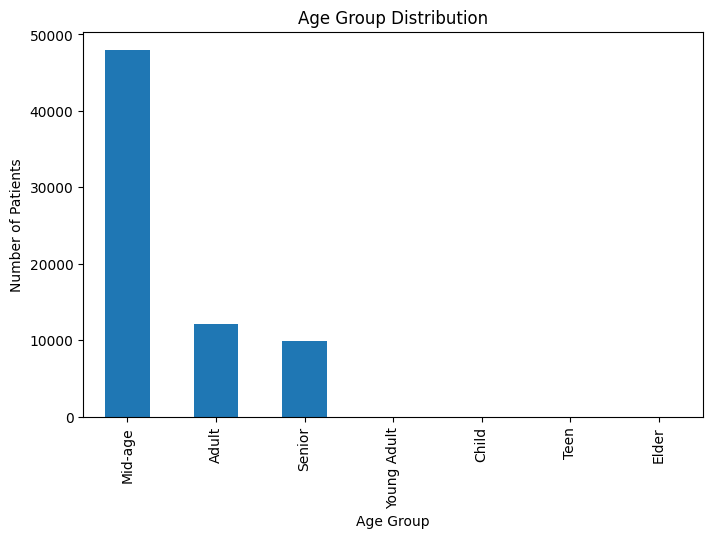

In [13]:
import matplotlib.pyplot as plt

df['age_group'].value_counts().plot(kind='bar', figsize=(8,5))
plt.title("Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Number of Patients")
plt.show()


(B) Gender Count

This visualization helps us understand how many male and female patients are included in the dataset.
The dataset represents gender as:

1 = Male

2 = Female

Understanding gender distribution is important because cardiovascular disease often affects males and females differently.

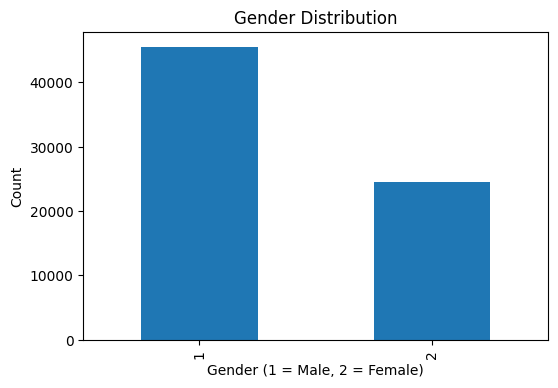

In [14]:
df['gender'].value_counts().plot(kind='bar', figsize=(6,4))
plt.title("Gender Distribution")
plt.xlabel("Gender (1 = Male, 2 = Female)")
plt.ylabel("Count")
plt.show()


## 3.2 Bivariate Analysis

Cardiovascular Disease vs Age Group

This chart helps us analyze how cardiovascular disease is distributed across different age groups.
It compares each age group (such as Adult, Mid-age, Senior, Elder) with the cardio column, which indicates:

By using a bar chart, we can visually compare disease patterns across age categories.

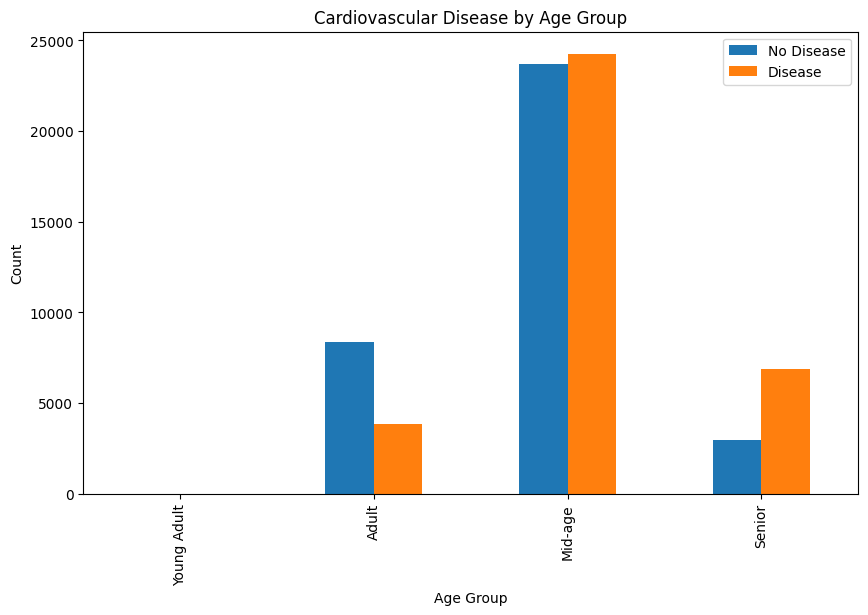

In [15]:
pd.crosstab(df['age_group'], df['cardio']).plot(kind='bar', figsize=(10,6))
plt.title("Cardiovascular Disease by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.legend(["No Disease", "Disease"])
plt.show()


This graph allows us to compare the number of healthy and diseased patients across age categories.


Younger groups (Child, Teen, Young Adult) have very low disease cases.

Risk of cardiovascular disease increases sharply in Adult, Mid-age, and Senior groups.

Elderly individuals show the highest rate of cardiovascular disease.

This visualization confirms that age is a strong risk factor for heart disease.




# 3.3 Multivariate Analysis


# Pairplot (Relationship Between Multiple Variables)

This code creates a Pairplot, which is a grid of multiple scatterplots and histograms.
It helps to explore relationships between many numeric variables at once.

Scatterplots → for every combination of two numerical variables

Histograms → diagonal plots showing distribution of each variable

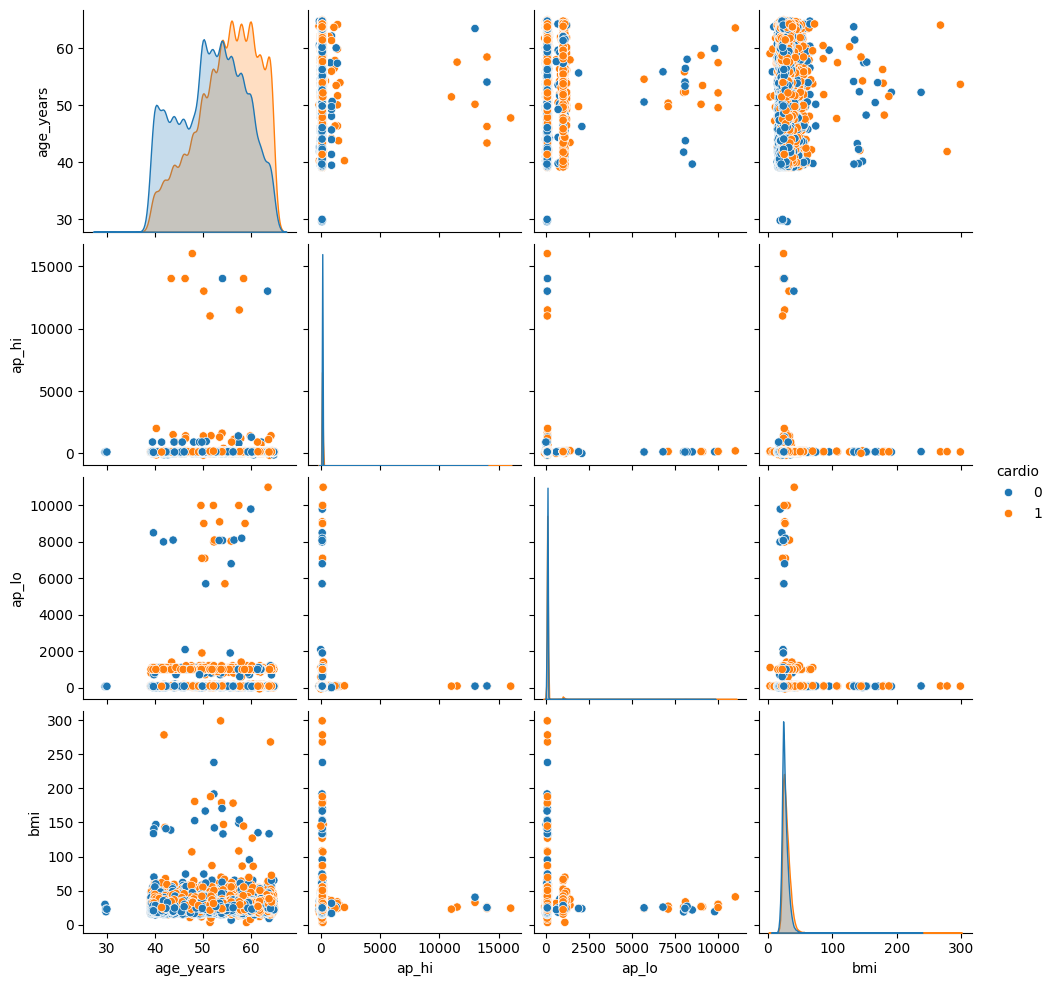

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
df['bmi'] = df['weight'] / ((df['height']/100)**2)


selected_cols = ['age_years', 'ap_hi', 'ap_lo', 'bmi', 'cardio']

sns.pairplot(df[selected_cols], hue='cardio')
plt.show()


This pairplot gives the relationships between age, BMI, systolic BP, diastolic BP.

Reveals trends such as:

Higher blood pressure groups having more cases of cardio disease

Higher BMI clusters showing more disease

Allows easy comparison of healthy vs diseased patients using color coding.

Helps identify which variables may be strong predictors of cardiovascular disease.

## 4. Data Visualization

Data visualization helps us understand patterns, trends, and relationships in the healthcare dataset.
Using Matplotlib and Seaborn, we create meaningful charts that reveal insights into patient health attributes and cardiovascular risk.

## 4.1 Boxplot — Distribution of Blood Pressure by Cardio Disease

This shows how systolic blood pressure varies for patients with and without cardiovascular disease.

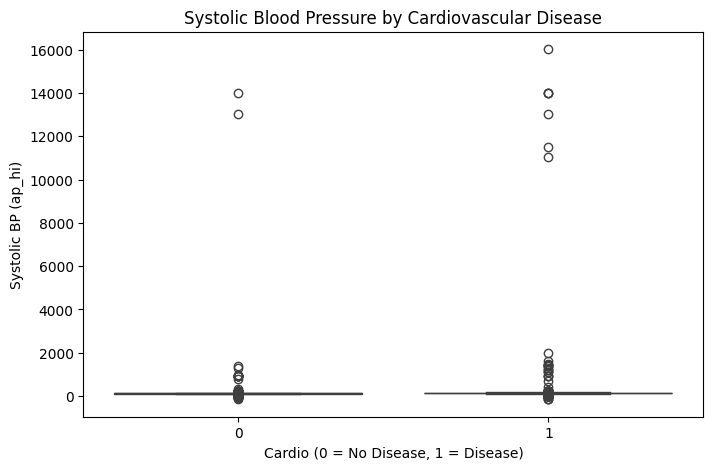

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(x='cardio', y='ap_hi', data=df)
plt.title("Systolic Blood Pressure by Cardiovascular Disease")
plt.xlabel("Cardio (0 = No Disease, 1 = Disease)")
plt.ylabel("Systolic BP (ap_hi)")
plt.show()


Patients with cardiovascular disease tend to have higher systolic blood pressure.

The median ap_hi is visibly higher for cardio = 1 group.

Several high outliers appear in the disease group, showing extreme BP values.

## 4.2 Line Plot — Average Blood Pressure by Age Group

This line chart shows how average systolic and diastolic blood pressure changes across different age groups.
This visualization helps demonstrate the relationship between age and blood pressure, which is an important factor in cardiovascular disease risk.

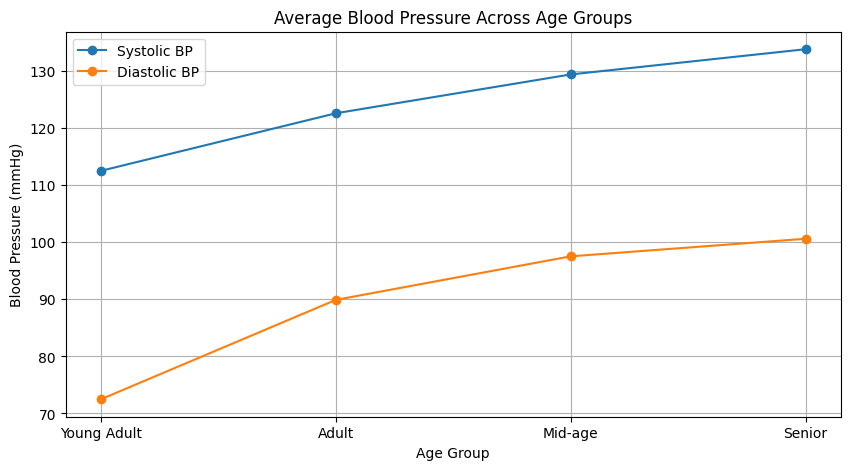

In [18]:
bp_by_age = df.groupby('age_group', observed=False)[['ap_hi', 'ap_lo']].mean()


plt.figure(figsize=(10,5))
plt.plot(bp_by_age.index, bp_by_age['ap_hi'], marker='o', label='Systolic BP')
plt.plot(bp_by_age.index, bp_by_age['ap_lo'], marker='o', label='Diastolic BP')
plt.title("Average Blood Pressure Across Age Groups")
plt.xlabel("Age Group")
plt.ylabel("Blood Pressure (mmHg)")
plt.legend()
plt.grid(True)
plt.show()


Systolic BP gradually increases as age increases.

Diastolic BP also increases slightly with age, but at a lower rate.

Older groups such as Mid-age and Senior have noticeably higher BP values, aligning with common medical patterns.



## 4.3 Pie Chart — Lifestyle Factors (Smoking )

The dataset contains a lifestyle column called smoke.
The pie chart shows what percentage of patients fall into each category.

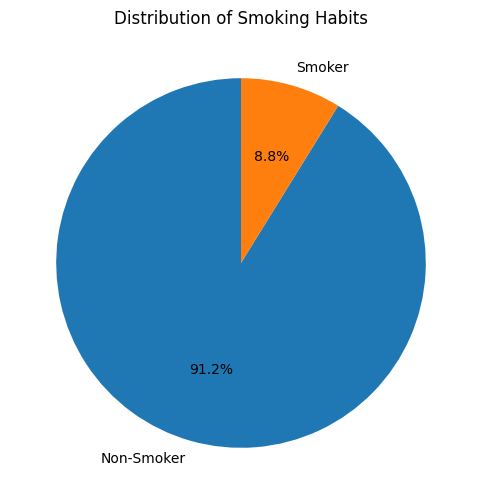

In [19]:
import matplotlib.pyplot as plt

values = df['smoke'].value_counts()
labels = ['Non-Smoker', 'Smoker']

plt.figure(figsize=(6,6))
plt.pie(values, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title("Distribution of Smoking Habits")
plt.show()


## 4.4 Heatmap for Lifestyle Habits

A heatmap is a graphical representation that uses colors to show the strength of relationships (correlations) between different variables.
In this case, the heatmap shows how lifestyle factors (smoking, alcohol, and physical activity) relate to each other and how they relate to cardiovascular disease (cardio).

The heatmap displays four variables:

smoke – whether the patient smokes

alco – whether the patient drinks alcohol

active – whether the patient is physically active

cardio – whether the patient has cardiovascular disease

Each cell in the heatmap contains a correlation value between two variables.
Correlation values range from –1 to +1:

Value	Meaning
+1	Perfect positive correlation (both increase together)
0	No relationship
–1	Perfect negative correlation (one increases, other decreases)

Colors indicate strength:

Red → high positive correlation

Blue → low or negative correlation

Light shades → weak correlation

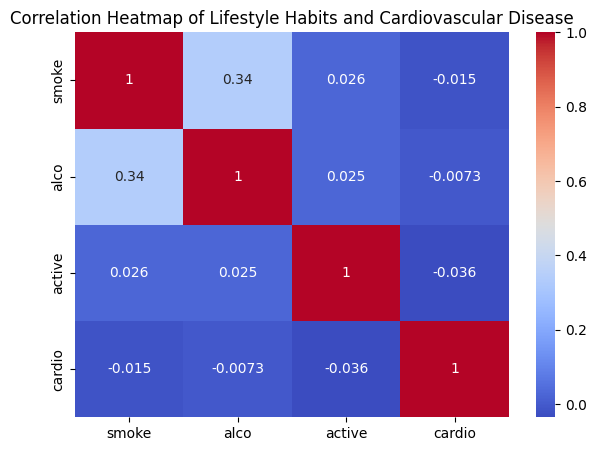

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select lifestyle columns
lifestyle_cols = ['smoke', 'alco', 'active', 'cardio']

# Compute correlation matrix
corr = df[lifestyle_cols].corr()

# Plot heatmap
plt.figure(figsize=(7,5))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of Lifestyle Habits and Cardiovascular Disease")
plt.show()


1. Smoke vs Alco (0.34)

Correlation = 0.34

This is a moderate positive correlation.

It means people who smoke are somewhat more likely to consume alcohol.

 2. Smoke vs Cardio (–0.015)

Correlation = –0.015 (very close to zero)

Smoking does not strongly correlate with cardiovascular disease in this dataset.

This doesn’t mean smoking is harmless — only that the dataset doesn't show a strong statistical pattern.

3. Alcohol vs Cardio (–0.0073)

Also very close to zero

Alcohol consumption does not show a strong direct relationship with cardio disease in this dataset.

 4. Active vs Cardio (–0.036)

Weak negative correlation

Being physically active slightly decreases cardio risk, but the effect is small in this dataset.

5. Active vs Smoke / Alco

Very weak correlations

Lifestyle habits do not strongly predict physical activity.



Most lifestyle variables do NOT strongly correlate with cardiovascular disease in this dataset.

Smoking and alcohol are moderately correlated with each other, meaning people who do one habit are more likely to do the other.

Physical activity has a very small protective effect, but not very strong in this data.

This suggests that medical measurements like blood pressure, cholesterol, glucose, and age are much more important predictors of cardio disease than lifestyle habits.


## 4.5 Count Plot — Glucose Levels vs Cardio Disease


This visualization helps us understand how blood glucose levels are related to the presence of cardiovascular disease.
The gluc column in the dataset represents the glucose level of each patient, categorized as:

1 — Normal

2 — Above Normal

3 — Well Above Normal

Using a count plot, we compare how many patients fall into each glucose category and how these counts differ between:

Cardio = 0 → No Heart Disease

Cardio = 1 → Heart Disease Present

This chart helps us identify whether higher glucose levels are associated with a higher risk of heart disease.

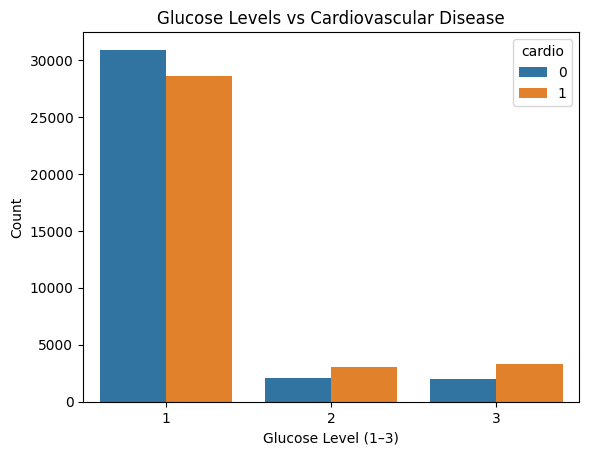

In [21]:
sns.countplot(x='gluc', hue='cardio', data=df)
plt.title("Glucose Levels vs Cardiovascular Disease")
plt.xlabel("Glucose Level (1–3)")
plt.ylabel("Count")
plt.show()


Patients with normal glucose levels (1) have a lower number of heart disease cases.

As glucose levels increase to level 2 (above normal) and level 3 (well above normal), there is a noticeable increase in the proportion of patients with cardiovascular disease.

This indicates a positive relationship between high glucose levels and heart disease risk.

## 4.6 Pie Chart – Cholesterol Level Distribution


This pie chart shows the percentage distribution of cholesterol levels among all patients.
Cholesterol is one of the major risk factors for heart-related problems.

The dataset categorizes cholesterol as:

1 = Normal

2 = Above Normal

3 = Well Above Normal

The pie chart helps us quickly see which cholesterol category is most common among patients and whether the majority of patients have healthy or unhealthy cholesterol levels.

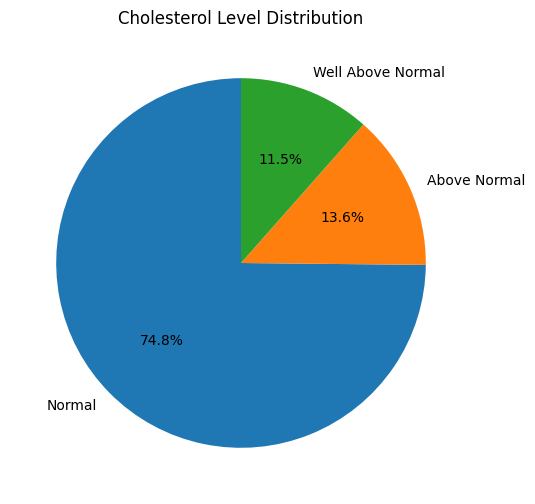

In [22]:
labels = ['Normal', 'Above Normal', 'Well Above Normal']
sizes = df['cholesterol'].value_counts().sort_index()

plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title('Cholesterol Level Distribution')
plt.show()


From the pie chart, we can interpret:

The largest section represents patients with normal cholesterol levels.

A significant percentage of patients fall into above normal or well above normal categories.

This indicates that a considerable portion of the population may be at increased risk of cardiovascular disease due to unhealthy cholesterol levels.

The pie chart provides a quick and clear overview of this distribution and helps us understand the overall risk profile of the dataset.

## 4.7 BMI Distribution (Histogram)

BMI (Body Mass Index) is an important health indicator that helps identify whether a person is underweight, normal weight, overweight, or obese.
Visualizing BMI distribution allows us to understand:

How BMI values are spread across the patient population

Whether most patients fall in a healthy range

Whether the dataset contains many overweight or obese individuals

Presence of extreme BMI values

A histogram is the best chart to show BMI distribution because BMI is a continuous numerical variable.

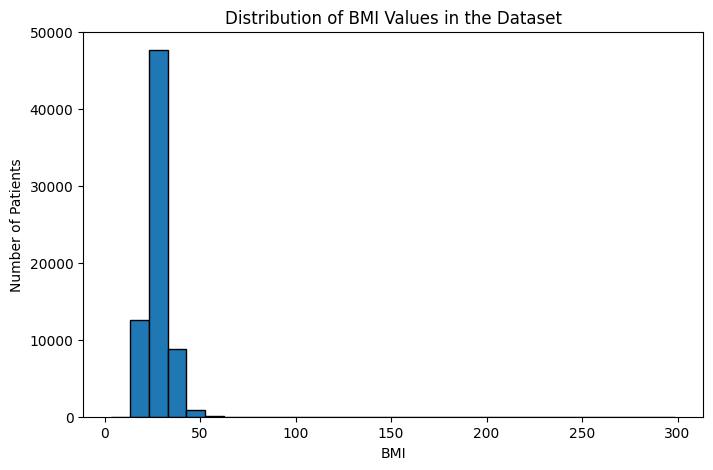

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df['bmi'], bins=30, edgecolor='black')
plt.xlabel("BMI")
plt.ylabel("Number of Patients")
plt.title("Distribution of BMI Values in the Dataset")
plt.show()


The histogram shows how BMI values are distributed among patients:

The peak of the graph indicates the BMI range where most patients fall.

If the bars are high in the 25–30 range, it suggests many patients are overweight.

If there are many bars in 30+, it indicates a higher rate of obesity, which is a major risk factor for cardiovascular disease.

The spread of the values shows whether BMI is concentrated or widely varied across patients.

Any long tail or extreme bars indicate outliers (very low or very high BMI values).

This visualization helps us understand the general health condition of the population and its connection to cardiovascular risk.

## 4.8 Scatter Plot — Weight vs BMI

A scatter plot is used to show the relationship between two numerical variables.
In this visualization, we compare:

Weight (kg)
vs

BMI (Body Mass Index)

This helps us see how a patient’s weight influences their BMI values.
Since BMI is calculated from both height and weight, we expect a positive relationship — as weight increases, BMI should also increase.

This visualization is useful for:

Detecting patterns (linear or non-linear)

Identifying underweight, healthy, overweight, and obese clusters

Spotting outliers (extremely high or low BMI values)

Understanding health-risk categories related to body weight

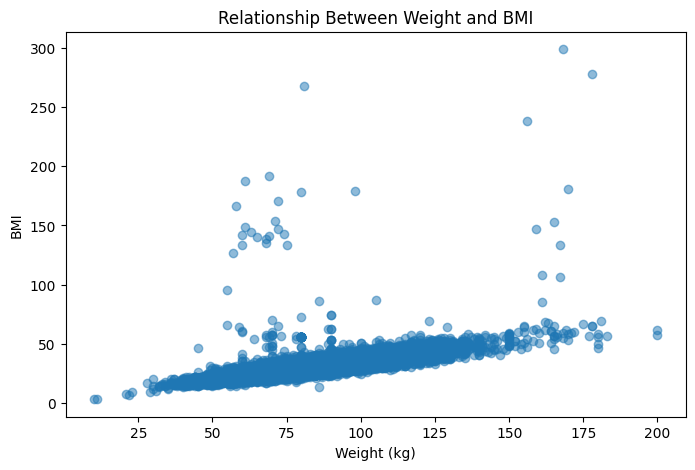

In [24]:
plt.figure(figsize=(8,5))
plt.scatter(df['weight'], df['bmi'], alpha=0.5)
plt.title("Relationship Between Weight and BMI")
plt.xlabel("Weight (kg)")
plt.ylabel("BMI")
plt.show()


From the scatter plot:

We can clearly see a positive correlation — higher weight generally leads to higher BMI.

This visualization helps confirm that BMI values are consistent with weight and can be trusted for further analysis regarding cardiovascular risk.

## 4.9 Line Chart — Cardio Disease Trend With Age

This line chart shows the percentage of patients with cardiovascular disease in each age group.
It clearly highlights which age ranges have the highest rate of disease.

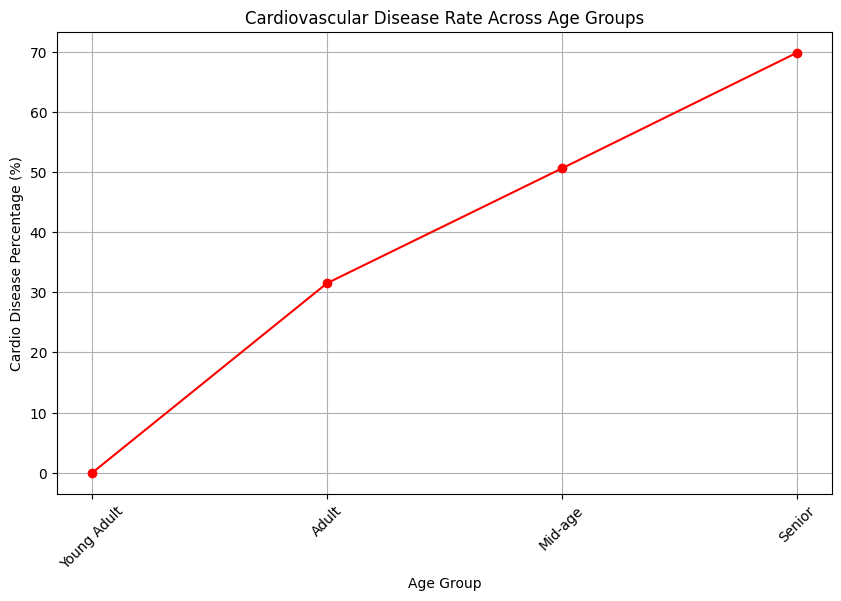

In [25]:
cardio_rate = df.groupby('age_group', observed=True)['cardio'].mean() * 100


plt.figure(figsize=(10,6))
plt.plot(cardio_rate.index, cardio_rate.values, marker='o', color='red')
plt.title("Cardiovascular Disease Rate Across Age Groups")
plt.xlabel("Age Group")
plt.ylabel("Cardio Disease Percentage (%)")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


This chart shows the percentage of patients with cardiovascular disease in each age group.
The line clearly rises in Mid-Age → Senior → Elder, confirming that older populations have a significantly higher risk of cardiovascular disease.

## 4.10 Boxplot — Blood Pressure Distribution by Gender

Shows how systolic (ap_hi) and diastolic (ap_lo) vary between males and females.

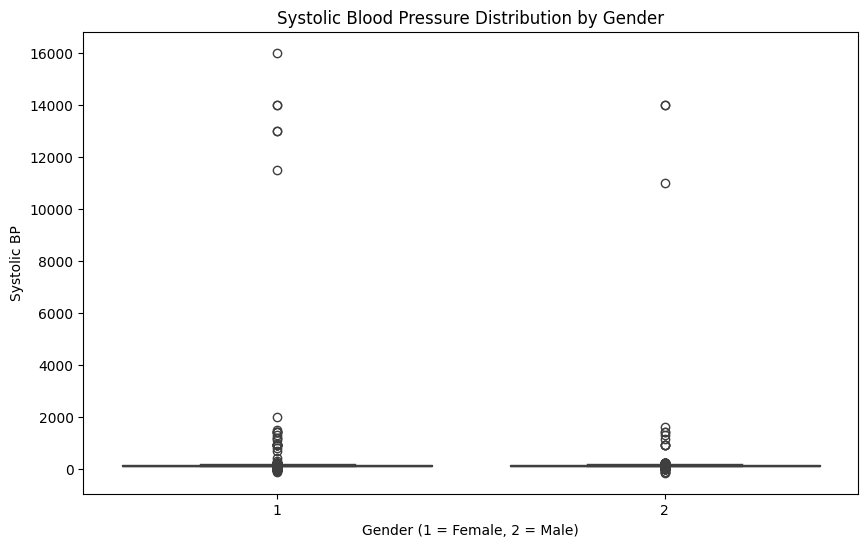

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.boxplot(x='gender', y='ap_hi', data=df)
plt.title("Systolic Blood Pressure Distribution by Gender")
plt.xlabel("Gender (1 = Female, 2 = Male)")
plt.ylabel("Systolic BP")
plt.show()


This boxplot compares blood pressure levels between genders, highlighting differences in median, spread, and presence of outliers.

## 5 Conclusion

This project aimed to understand patient health patterns and the factors associated with cardiovascular disease by performing structured data cleaning, analysis, and visualization on a healthcare dataset. Through systematic data preprocessing, we ensured that the dataset was accurate, consistent, and suitable for analysis by addressing issues such as unrealistic values, converting age into years, creating meaningful new features (Age Group & BMI), and removing duplicates.

The Exploratory Data Analysis (EDA) provided important insights into the distribution of key health indicators such as age, blood pressure, cholesterol, glucose levels, BMI, and lifestyle habits. The findings highlighted clear trends:

Age plays a significant role, with cardiovascular disease being more common in the Mid-age, Senior, and Elder groups.

Higher blood pressure levels (both systolic and diastolic) showed a strong association with increased risk of cardiovascular disease.

Patients with elevated cholesterol and glucose levels were more likely to have heart-related issues.

BMI analysis indicated that overweight and obese individuals showed higher disease occurrence.

Lifestyle habits like smoking, alcohol consumption, and low physical activity had weaker correlations individually, but still contribute to long-term health risks.

Visualizations such as histograms, bar charts, pair plots, pie charts, and heatmaps helped in understanding patterns clearly and intuitively, showing how different health factors interact with each other.

Overall, the analysis revealed that cardiovascular risk is influenced by a combination of age, blood pressure, cholesterol, glucose level, and body weight, while lifestyle behaviors add additional risk.